# Análisis Exploratorio de Datos (EDA)
## Dataset: Pizza Place Sales (Kaggle)

Este notebook realiza el análisis exploratorio del dataset seleccionado 
para el TFG de predicción de demanda en pizzerías con delivery.

El objetivo es entender la estructura de los datos, detectar posibles 
problemas de calidad y identificar patrones temporales que justifiquen 
el uso de variables contextuales en el modelo predictivo.

In [1]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de datos

Se cargan los dos ficheros principales del dataset: `orders.csv` con 
la fecha y hora de cada pedido, y `order_details.csv` con el detalle 
de los productos pedidos en cada orden.

In [2]:
# Carga de los datasets
orders = pd.read_csv('../data/kaggle_pizza_place_sales/orders.csv')
order_details = pd.read_csv('../data/kaggle_pizza_place_sales/order_details.csv')

print(f"orders: {orders.shape[0]} filas, {orders.shape[1]} columnas")
print(f"order_details: {order_details.shape[0]} filas, {order_details.shape[1]} columnas")

orders: 21350 filas, 3 columnas
order_details: 48620 filas, 4 columnas


## 2. Estructura de los datos

In [3]:
# Primeras filas de orders
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [4]:
# Primeras filas de order_details
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


### Observaciones
- `orders` contiene **21.350 pedidos** con 3 columnas: `order_id`, `date` y `time`.
- `order_details` contiene **48.620 líneas de detalle** con 4 columnas: 
  `order_details_id`, `order_id`, `pizza_id` y `quantity`.
- Los datos cubren pedidos desde el 1 de enero de 2015.
- La fecha y la hora están en columnas separadas, habrá que combinarlas 
  para crear una variable datetime correcta.
- Cada pedido puede tener varias líneas en order_details 
  (un cliente puede pedir varias pizzas).

## 3. Calidad de los datos

Se analizan los valores nulos, duplicados y los tipos de datos 
para detectar problemas antes de construir el modelo.

In [5]:
# Análisis de valores nulos y tipos de datos
print("=== ORDERS ===")
print(orders.dtypes)
print("\nValores nulos:")
print(orders.isnull().sum())

print("\n=== ORDER DETAILS ===")
print(order_details.dtypes)
print("\nValores nulos:")
print(order_details.isnull().sum())

=== ORDERS ===
order_id    int64
date          str
time          str
dtype: object

Valores nulos:
order_id    0
date        0
time        0
dtype: int64

=== ORDER DETAILS ===
order_details_id    int64
order_id            int64
pizza_id              str
quantity            int64
dtype: object

Valores nulos:
order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64


### Observaciones
- **Sin valores nulos** en ninguna de las dos tablas. No será necesario 
  aplicar técnicas de imputación de datos.
- `date` y `time` están como texto (str), habrá que convertirlas a 
  formato datetime para poder trabajar con series temporales.
- El resto de tipos de datos son correctos.

In [6]:
# Comprobación de duplicados
print(f"Duplicados en orders: {orders.duplicated().sum()}")
print(f"Duplicados en order_details: {order_details.duplicated().sum()}")

Duplicados en orders: 0
Duplicados en order_details: 0


### Observaciones
- **Sin duplicados** en ninguna de las dos tablas.
- El dataset presenta una calidad de datos excelente, lo que permite 
  pasar directamente a la transformación de variables sin necesidad 
  de aplicar ningún proceso de limpieza previo.

## 4. Preparación de la variable temporal

Se combinan las columnas `date` y `time` en una única variable 
datetime para poder analizar la demanda a lo largo del tiempo.

In [7]:
# Combinar fecha y hora en una sola columna datetime
orders['datetime'] = pd.to_datetime(orders['date'] + ' ' + orders['time'])
orders['date'] = pd.to_datetime(orders['date'])

# Extraer variables temporales útiles
orders['hour'] = orders['datetime'].dt.hour
orders['day_of_week'] = orders['datetime'].dt.day_name()
orders['month'] = orders['datetime'].dt.month

print(orders.head())
print(f"\nRango temporal: {orders['date'].min()} → {orders['date'].max()}")

   order_id       date      time            datetime  hour day_of_week  month
0         1 2015-01-01  11:38:36 2015-01-01 11:38:36    11    Thursday      1
1         2 2015-01-01  11:57:40 2015-01-01 11:57:40    11    Thursday      1
2         3 2015-01-01  12:12:28 2015-01-01 12:12:28    12    Thursday      1
3         4 2015-01-01  12:16:31 2015-01-01 12:16:31    12    Thursday      1
4         5 2015-01-01  12:21:30 2015-01-01 12:21:30    12    Thursday      1

Rango temporal: 2015-01-01 00:00:00 → 2015-12-31 00:00:00


### Observaciones
- El dataset cubre exactamente **un año completo: del 1 de enero 
  al 31 de diciembre de 2015**.
- Se han extraído correctamente las variables `hour`, `day_of_week` 
  y `month` que se usarán como variables contextuales en el modelo.
- Los primeros pedidos del día aparecen a las 11h, lo que es 
  coherente con el horario habitual de apertura de una pizzería.

## 5. Análisis de patrones temporales
### 5.1 Pedidos por día de la semana

C:\Users\mja\AppData\Local\Temp\ipykernel_25296\4274156152.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pedidos_dia.index, y=pedidos_dia.values, palette='Blues_d')


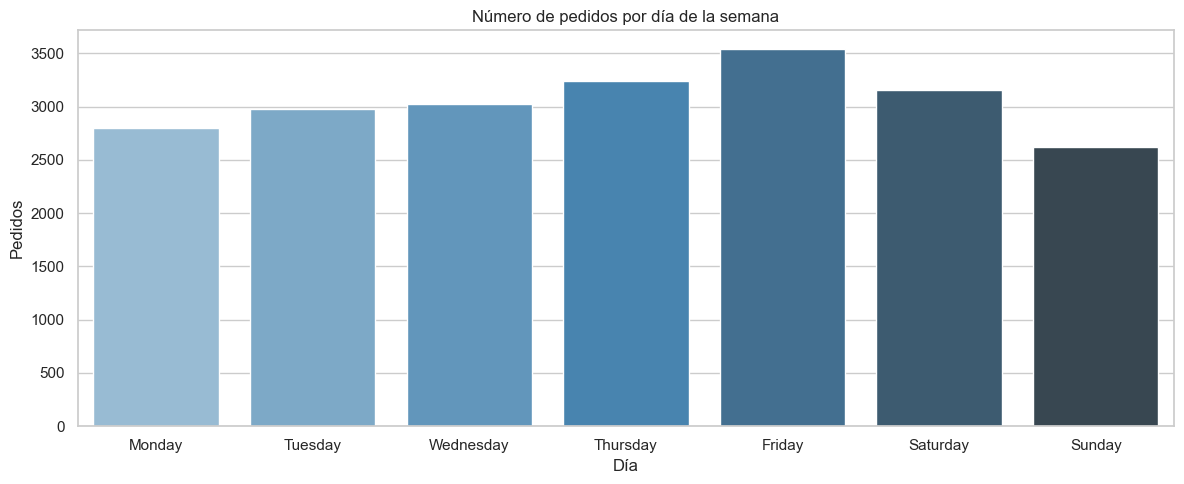

In [8]:
# Orden correcto de los días
dias_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pedidos_dia = orders['day_of_week'].value_counts().reindex(dias_orden)

sns.barplot(x=pedidos_dia.index, y=pedidos_dia.values, palette='Blues_d')
plt.title('Número de pedidos por día de la semana')
plt.xlabel('Día')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.savefig('../notebooks/fig_pedidos_dia_semana.png', dpi=150)
plt.show()

### Observaciones
- **El viernes es el día de mayor demanda**, con más de 3.500 pedidos 
  a lo largo del año, seguido del jueves y el sábado.
- **El domingo es el día de menor demanda**, con aproximadamente 
  2.600 pedidos.
- Se observa una tendencia ascendente de lunes a viernes con una 
  caída el fin de semana, lo que confirma la importancia del día 
  de la semana como variable predictora, tal y como recoge la 
  literatura revisada en el estado del arte.

### 5.2 Pedidos por franja horaria

C:\Users\mja\AppData\Local\Temp\ipykernel_25296\1841869406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pedidos_hora.index, y=pedidos_hora.values, palette='Blues_d')


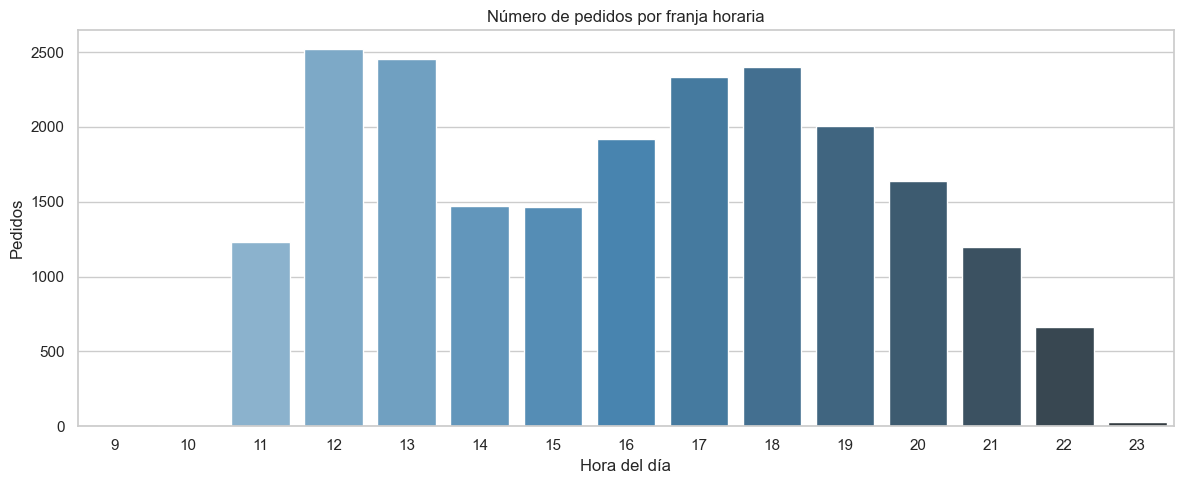

In [9]:
pedidos_hora = orders['hour'].value_counts().sort_index()

sns.barplot(x=pedidos_hora.index, y=pedidos_hora.values, palette='Blues_d')
plt.title('Número de pedidos por franja horaria')
plt.xlabel('Hora del día')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.savefig('../notebooks/fig_pedidos_hora.png', dpi=150)
plt.show()

### Observaciones
- Se identifican **dos picos claros de demanda** a lo largo del día:
  - **Mediodía: 12h-13h**, coincidiendo con la hora de comer.
  - **Tarde-noche: 17h-18h**, coincidiendo con la cena.
- Los horarios corresponden a un establecimiento estadounidense, 
  por lo que los picos de 12h-13h y 17h-18h son coherentes 
  con los hábitos de consumo del contexto geográfico del dataset.
- El local abre a las 11h y cierra cerca de las 23h.
- La franja horaria es una variable contextual clave para el modelo, 
  ya que la demanda varía significativamente según la hora del día,
  confirmando lo documentado en el estado del arte.

### 5.3 Pedidos por mes

C:\Users\mja\AppData\Local\Temp\ipykernel_25296\4262235853.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meses, y=pedidos_mes.values, palette='Blues_d')


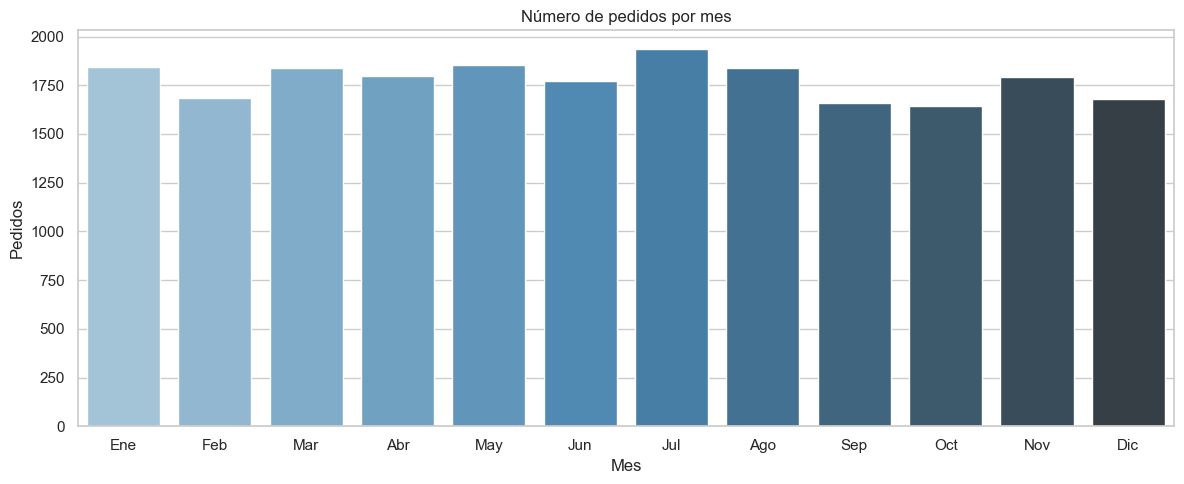

In [10]:
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

pedidos_mes = orders['month'].value_counts().sort_index()

sns.barplot(x=meses, y=pedidos_mes.values, palette='Blues_d')
plt.title('Número de pedidos por mes')
plt.xlabel('Mes')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.savefig('../notebooks/fig_pedidos_mes.png', dpi=150)
plt.show()

### Observaciones
- La demanda mensual es **relativamente estable** a lo largo del año, 
  sin una estacionalidad pronunciada.
- **Julio es el mes de mayor demanda**, con casi 1.900 pedidos.
- **Septiembre y octubre son los meses más bajos**, en torno a 1.650 pedidos.
- La variación entre el mes más alto y el más bajo es de apenas un 15%, 
  lo que indica que la estacionalidad mensual tiene menos impacto que 
  el día de la semana o la franja horaria.
- Este patrón refuerza la necesidad de incorporar variables contextuales 
  externas como el clima o los festivos para explicar las variaciones 
  de demanda que los patrones temporales por sí solos no capturan.

## 6. Serie temporal diaria

Se analiza la evolución del número de pedidos día a día a lo largo 
de todo el año. Esta es la variable objetivo que utilizará el modelo 
Prophet para realizar las predicciones.

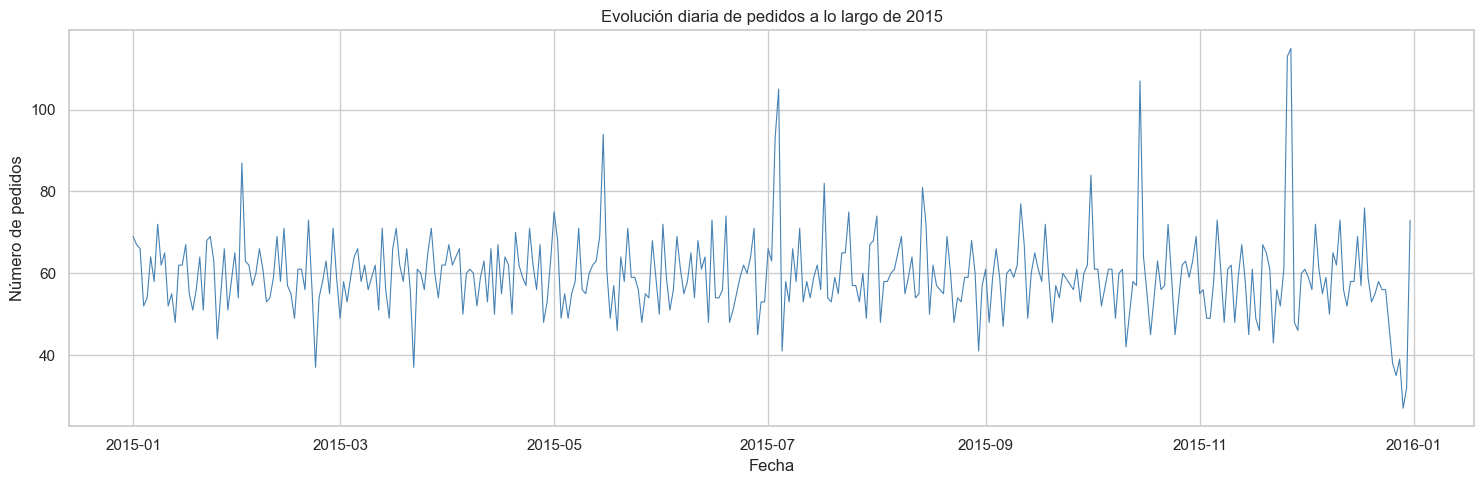

Media diaria de pedidos: 59.6
Máximo diario: 115 pedidos
Mínimo diario: 27 pedidos


In [11]:
# Agrupar pedidos por día
pedidos_diarios = orders.groupby('date').size().reset_index(name='num_pedidos')

# Visualizar la serie temporal
plt.figure(figsize=(15, 5))
plt.plot(pedidos_diarios['date'], pedidos_diarios['num_pedidos'], 
         color='steelblue', linewidth=0.8)
plt.title('Evolución diaria de pedidos a lo largo de 2015')
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos')
plt.tight_layout()
plt.savefig('../notebooks/fig_serie_temporal_diaria.png', dpi=150)
plt.show()

print(f"Media diaria de pedidos: {pedidos_diarios['num_pedidos'].mean():.1f}")
print(f"Máximo diario: {pedidos_diarios['num_pedidos'].max()} pedidos")
print(f"Mínimo diario: {pedidos_diarios['num_pedidos'].min()} pedidos")

### Observaciones
- La media diaria es de **59,6 pedidos**, con una variación considerable 
  entre el mínimo de 27 y el máximo de 115 pedidos en un mismo día.
- La serie muestra un comportamiento **estable a lo largo del año** sin 
  una tendencia clara al alza o a la baja.
- Se aprecian **picos puntuales** que no responden al patrón semanal 
  habitual, lo que sugiere la influencia de eventos especiales o 
  festivos concretos.
- La caída pronunciada al final del año coincide probablemente con el 
  período navideño, lo que refuerza la necesidad de incorporar 
  festivos como variable contextual en el modelo.
- Esta serie temporal es la variable objetivo `y` que utilizará 
  Prophet para entrenar el modelo predictivo.